<a href="https://colab.research.google.com/github/pendulumswings/pendulumswings.github.io/blob/main/scripts/chapter2/energy_phase.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Energy and Phase Space for the Simple Pendulum

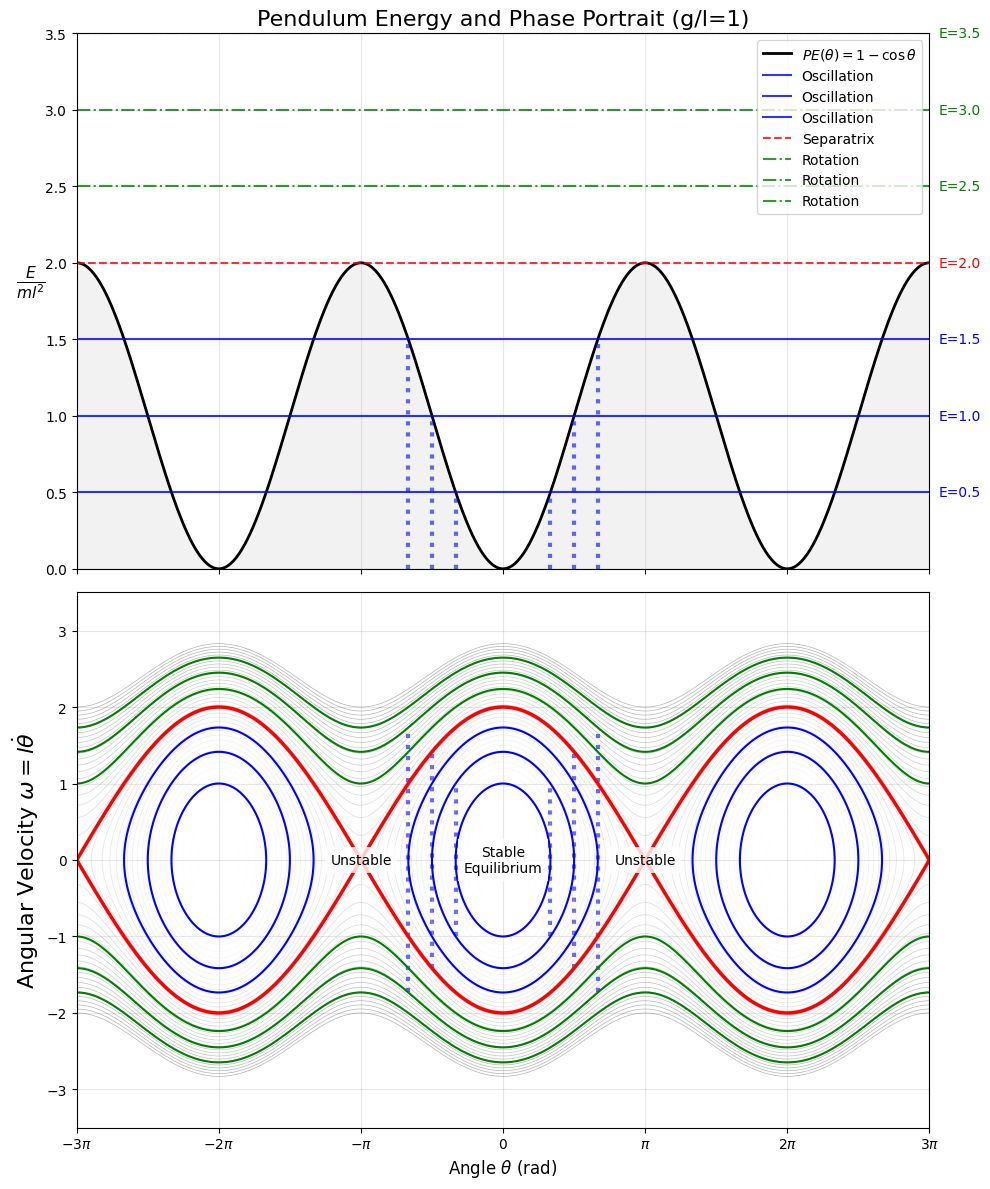

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def plot_pendulum_phase_energy():
    # Grid setup
    # We extend theta range to show continuous rotation
    theta_max = 3.0 * np.pi
    theta = np.linspace(-theta_max, theta_max, 600)
    omega = np.linspace(-10, 10, 600)
    Theta, Omega = np.meshgrid(theta, omega)

    # Energy Calculation:
    # E/(ml^2) = 0.5 * omega^2 + (1 - cos(theta)) [Normalized units g/l=1]
    PE = 1 - np.cos(theta)
    KE = 0.5 * Omega**2 + (1 - np.cos(Theta))

    # Define Energy Levels
    # E < 2: Oscillations (Trapped in the well)
    energies_osc = [0.5, 1.0, 1.5]
    # E = 2: Separatrix (The infinite climb)
    energy_sep = 2.0
    # E > 2: Rotations (Spinning over the top)
    energies_rot = [2.5, 3.0, 3.5]

    all_energies = energies_osc + [energy_sep] + energies_rot

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 12), sharex=True)
    plt.subplots_adjust(hspace=0.1)

    # --- Top Panel: Potential Energy ---
    # Plot Potential Well U(theta)
    ax1.plot(theta, PE, 'k-', linewidth=2, label=r'$PE(\theta) = 1 - \cos\theta$')
    ax1.fill_between(theta, 0, PE, color='gray', alpha=0.1)


    # Plot Horizontal Energy Lines
    for E in all_energies:
        if E < 2.0:
            color = 'blue'  # Oscillation
            style = '-'
            label = 'Oscillation'
        elif E == 2.0:
            color = 'red'   # Separatrix
            style = '--'
            label = 'Separatrix'
        else:
            color = 'green' # Rotation
            style = '-.'
            label = 'Rotation'

        # Draw the constant Energy line
        ax1.axhline(y=E, color=color, linestyle=style, label=label,alpha=0.8, linewidth=1.5)
        ax1.text(theta_max + 0.2, E, f'E={E}', va='center', color=color, fontsize=10)
        ax1.legend()
        # --- Interaction Logic (Vertical Dotted Lines) ---
        if E < 2.0:
            # For oscillations, finding turning points where U = E
            # 1 - cos(theta) = E  ->  cos(theta) = 1 - E
            theta_turn = np.arccos(1 - E)

            # We plot lines for the central well (-pi to pi)
            # Left turning point
            ax1.plot([-theta_turn, -theta_turn], [0, E], ':', color=color, alpha=0.6,linewidth=3)
            ax2.plot([-theta_turn, -theta_turn], [-np.sqrt(2*E), np.sqrt(2*E)], ':', color=color, alpha=0.6,linewidth=3)

            # Right turning point
            ax1.plot([theta_turn, theta_turn], [0, E], ':', color=color, alpha=0.6,linewidth=3)
            ax2.plot([theta_turn, theta_turn], [-np.sqrt(2*E), np.sqrt(2*E)], ':', color=color, alpha=0.6,linewidth=3)

    ax1.set_ylabel(r'$\frac{E}{ml^{2}}$', rotation='horizontal',labelpad=10,fontsize=16)
    ax1.set_title('Pendulum Energy and Phase Portrait (g/l=1)', fontsize=16)
    ax1.set_ylim(0, 3.5)
    ax1.grid(True, alpha=0.3)

    # --- Bottom Panel: Phase Portrait ---
    # We plot contours for a dense range of energies to show flow
    dense_levels = np.sort(np.concatenate([all_energies, np.linspace(0, 4, 40)]))

    # Plot background contours
    ax2.contour(Theta, Omega, KE, levels=dense_levels, cmap='Greys', alpha=0.3, linewidths=0.5)

    # Highlight specific orbits
    # Oscillations (Blue)
    ax2.contour(Theta, Omega, KE, levels=energies_osc, colors='blue', linewidths=1.5)
    # Separatrix (Red)
    ax2.contour(Theta, Omega, KE, levels=[energy_sep], colors='red', linewidths=2.5)
    # Rotations (Green)
    ax2.contour(Theta, Omega, KE, levels=energies_rot, colors='green', linewidths=1.5)

    ax2.set_xlabel(r'Angle $\theta$ (rad)', fontsize=12)
    ax2.set_ylabel(r'Angular Velocity $\omega=l\dot{\theta}$', fontsize=16)
    ax2.grid(True, alpha=0.3)

    # Annotate Regions
    ax2.text(0, 0, 'Stable\nEquilibrium', ha='center', va='center', bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))
    ax2.text(-np.pi, 0, 'Unstable', ha='center', va='center', bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))
    ax2.text(np.pi, 0, 'Unstable', ha='center', va='center', bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))

    # Set X-Ticks to multiples of Pi
    ticks = np.arange(-3, 4, 1) * np.pi
    labels = [r'$-3\pi$', r'$-2\pi$', r'$-\pi$', r'$0$', r'$\pi$', r'$2\pi$', r'$3\pi$']
    ax2.set_xticks(ticks)
    ax2.set_xticklabels(labels)
    ax2.set_xlim(-theta_max, theta_max)
    ax2.set_ylim(-3.5, 3.5)

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    plot_pendulum_phase_energy()